In [7]:
#update repo
#1- push commit from your pc
#2- cd to repo => cd ~/tmu/
#3- git pull
#4- sometime it requires git reset --hard to stash changes
#4- pip install develop .

import numpy as np
import keras
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
from keras.datasets import imdb
from time import time
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import f1_score
from sklearn.metrics.pairwise import cosine_similarity
from tmu.models.autoencoder.autoencoder import TMAutoEncoder
from tmu.util.cuda_profiler import CudaProfiler
import random
import os

# target_words = ['london', 'city', 'lousy', 'abysmal', 'crap', 'outstanding', 'brilliant', 'excellent', 'superb', 'magnificent', 'marvellous', 'truck', 'plane', 'car', 'cars', 'motorcycle',  'scary', 'frightening', 'terrifying', 'horrifying', 'funny', 'comic', 'hilarious', 'witty']
target_words = [
	'awful',
	'terrible',
	'lousy',
	'abysmal',
	'crap',
	'outstanding',
	'brilliant',
	'excellent',
	'superb',
	'magnificent',
	'marvellous',
	'truck',
	'plane',
	'car',
	'cars',
	'motorcycle',
	'scary',
	'frightening',
	'terrifying',
	'horrifying',
	'funny',
	'comic',
	'hilarious',
	'witty'
]

In [8]:
sentnese_level = False
random_target = False
num_words_to_select = 100

remove_categories = True
categories = 4
accumulation = categories * 6

clause_weight_threshold = 0
number_of_examples = 20000
factor = 1
T = factor*40
s = 5.0

In [9]:
experts_dataset = []

def prepare_bbc():
    training_data = []
    import re
    data_dir ="bbc"
    for category in os.listdir(data_dir):
        category_dir = os.path.join(data_dir, category)
        
        for file_name in os.listdir(category_dir):
            file_path = os.path.join(category_dir, file_name)
            
            with open(file_path, "r") as file:
                content = file.read()
                preprocessed_content = re.sub(r'\W+', ' ', content.lower())
                training_data.append(preprocessed_content)
    experts_dataset.append((training_data,"BBC Sport"))

def prepare_20newsgroups():
    from sklearn.datasets import fetch_20newsgroups
    import re

    training_data = []
    newsgroups_data = fetch_20newsgroups(subset='train', remove=('headers', 'footers', 'quotes'))
    documents = newsgroups_data.data
    for document in documents:
        preprocessed_content = re.sub(r'\W+', ' ', document.lower())
        training_data.append(preprocessed_content)
    experts_dataset.append((training_data,"20 Newsgroups"))

def prepare_ag_news():
    # pip install tensorflow_datasets
    # pip install datasets
    import tensorflow_datasets as tfds
    training_data = []
    data = tfds.load('huggingface:ag_news', split='train')
    for sample in data:
        training_data.append(' '.join(sample['text'].numpy().decode('utf-8').split()))
    experts_dataset.append((training_data,"AG News"))

def prepare_imdb():
    training_data = []
    NUM_WORDS=10000
    INDEX_FROM=2
    train,test = keras.datasets.imdb.load_data(num_words=NUM_WORDS, index_from=INDEX_FROM)

    train_x,train_y = train
    word_to_id = keras.datasets.imdb.get_word_index()
    word_to_id = {k:(v+INDEX_FROM) for k,v in word_to_id.items()}
    word_to_id["<PAD>"] = 0
    word_to_id["<START>"] = 1
    word_to_id["<UNK>"] = 2

    id_to_word = {value:key for key,value in word_to_id.items()}

    for i in range(train_y.shape[0]):
        terms = []
        for word_id in train_x[i]:
            terms.append(id_to_word[word_id].lower())        

        training_documents.append(terms)
    experts_dataset.append((training_data,"IMDB"))

In [ ]:
print("start preparing BBC Sport datatsets")
prepare_bbc()
print("start preparing 20 Newsgroups datatsets")
prepare_20newsgroups()
print("start preparing AG News datatsets")
prepare_ag_news()
print("start preparing IMDB datatsets")
prepare_imdb()
print("datatsets completed")

In [ ]:
if(sentnese_level):
    #pip install nltk
    import nltk
    nltk.download('punkt')
    from nltk.tokenize import sent_tokenize, word_tokenize
    
    for i in range(train_y.shape[0]):
        decoded_review = ' '.join([id_to_word.get(i - 3, '?') for i in train_x[i]])
        sentences = sent_tokenize(decoded_review)
        # Only add sentences with more than three words
        for sentence in sentences:
            words = word_tokenize(sentence)
            if len(words) > 3:
                training_documents.append(words)
                
else:
    for i in range(train_y.shape[0]):
        terms = []
        for word_id in train_x[i]:
            terms.append(id_to_word[word_id].lower())        

        training_documents.append(terms)
        
print(training_documents[0])
print("The number of documents = ",len(training_documents))

In [24]:
def tokenizer(s):
    return s
    
vectorizer_X = CountVectorizer(tokenizer=tokenizer, lowercase=False, binary=remove_categories)
X_train = vectorizer_X.fit_transform(training_documents)
feature_names = vectorizer_X.get_feature_names_out()
number_of_features = vectorizer_X.get_feature_names_out().shape[0]
# X_test = vectorizer_X.transform(testing_documents)

if (random_target == True):
    available_words = list(vectorizer_X.vocabulary_.keys())
    target_words = random.sample(available_words, min(num_words_to_select, len(available_words)))
    print(target_words)
 

output_active = np.empty(len(target_words), dtype=np.uint32)
for i in range(len(target_words)):
    target_word = target_words[i]
    if target_word in vectorizer_X.vocabulary_:
        target_id = vectorizer_X.vocabulary_[target_word]
        output_active[i] = target_id
    else:
        # Handle the case when the word is not in the vocabulary
        print(f"Warning: '{target_word}' not found in voc abulary.")
print("tokenizing target words completed")

/opt/conda/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:525: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


tokenizing target words completed


In [25]:
import os
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

num_segments = len(target_words)
step_size = int(360 / num_segments)
color_dict = {}
hue = 0
for word in target_words:
    # color = plt.get_cmap('hsv')(hue / 360.0)
    # r, g, b, _ = color
    # r = int(r * 255)
    # g = int(g * 255)
    # b = int(b * 255)
    # color_dict[word] = (r, g, b)
    # hue += step_size
    color = plt.get_cmap('hsv')(hue / 360.0)
    color = mcolors.to_rgb(color)
    hex_color = mcolors.rgb2hex(color)
    color_dict[word] = hex_color
    hue += step_size

In [26]:
clauses = 80

if remove_categories:
    tm = TMAutoEncoder(clauses, T, s, output_active, max_included_literals=3, accumulation=accumulation, feature_negation=False, platform='CPU', output_balancing=True)
else:
    tm = TMAutoEncoder(clauses, T, s, output_active, max_included_literals=3, accumulation=accumulation, feature_negation=False, platform='CPU', output_balancing=True, categories=categories)
epochs = 10
print("\nAccuracy Over %d Epochs:" % epochs)
total_training = 0
for e in range(epochs):
    start_training = time()
    tm.fit(X_train, number_of_examples=number_of_examples)
    stop_training = time()
    total_training = total_training + (stop_training - start_training)

    print("\nEpoch #%d\n" % (e+1))

    # print("Calculating precision and recall\n")
    # precision = []
    # recall = []
    # if(remove_categories):
    #     for i in range(len(target_words)):
    #         precision.append(tm.clause_precision(i, True, X_train, number_of_examples=500))

    #     for i in range(len(target_words)):
    #         recall.append(tm.clause_recall(i, True, X_train, number_of_examples=500))
    # else:
    #     for i in range(len(target_words)):
    #         pres, rec = tm.clause_precision_recall(i, True, X_train, number_of_examples=1)
    #         precision.append(pres)
    #         recall.append(rec)
  
    print("Algorithm: %s " % ("Original without categories" if (remove_categories == True) else "With"), end="")
    if(remove_categories == False): 
        print("%d categories" % categories) 
    else: 
        print("\n")
    print("Epochs: %d" % epochs)
    print("Example: %d" % number_of_examples)
    print("Target words: %d" % len(target_words))
    print("Accumulation: %d" % accumulation)
    print("Clauses: %d" % clauses)
    
    print("\n=====================================\nClauses\n=====================================")
    # for j in range(clauses):
    #     print("Clause #%-2d " % (j), end=' ')
    #     # for i in range(len(target_words)):
    #     #     print("%s:W%d:P%.2f:R%.2f " % (target_words[i], tm.get_weight(i, j), precision[i][j], recall[i][j]), end=' ')

    #     l = [] 
    #     number_of_literals = 0 
    #     for k in range(tm.clause_bank.number_of_literals):
    #         if tm.get_ta_action(j, k) == 1:
    #             number_of_literals = number_of_literals + 1
    #             # if k < tm.clause_bank.number_of_features:
    #             #     l.append("%s(%d)" % (feature_names[k], tm.clause_bank.get_ta_state(j, k)))
    #             # else:
    #             #     l.append("¬%s(%d)" % (feature_names[k-tm.clause_bank.number_of_features], tm.clause_bank.get_ta_state(j, k)))
    #     print(": No of features:%-6d" % (number_of_literals), end=" ==> \n")
        # print(" ∧ ".join(l))

    profile = np.empty((len(target_words), clauses))
    for i in range(len(target_words)):
        weights = tm.get_weights(i)
        profile[i,:] = np.where(weights >= clause_weight_threshold, weights, 0)
    
    similarity = cosine_similarity(profile)

    print("\n=====================================\nWord Similarity\n=====================================")
    max_word_length = len(max(target_words, key=len))
    list_of_words = []
    target_words_with_min_max = []
    for i in range(len(target_words)):
        row_of_similarity = []
        sorted_index = np.argsort(-1*similarity[i,:])
        min_similarity = 1.0
        max_similarity = 0.0
        word_similarity = []
        for j in range(1, len(target_words)):
            row_of_similarity.append(target_words[sorted_index[j]])
            word_similarity.append("{:<{}}({:.2f})  ".format(target_words[sorted_index[j]], max_word_length, similarity[i, sorted_index[j]]))
            if(min_similarity > similarity[i,sorted_index[j]]):
                min_similarity = similarity[i,sorted_index[j]]
            if(max_similarity < similarity[i,sorted_index[j]]):
                max_similarity = similarity[i,sorted_index[j]]
                
        output_line = f"{target_words[i]:<{max_word_length}}: Min:{min_similarity:.2f}, Max:{max_similarity:.2f}"
        print(output_line, end='     ==> ')
        # print(f"{target_words[i]:<{max_word_length}}:", end=' ')
        # print("Min:%.2f, Max:%.2f" % (min_similarity,max_similarity), end='     ==> ')
        print(word_similarity)
        list_of_words.append(row_of_similarity)
        target_words_with_min_max.append(output_line)
    
    # m, s = divmod(total_training, 60)
    # h, m = divmod(m, 60)
    # duration_str = f"{h:02d}:{m:02d}:{s:02d}"
    print("\nTraining Time:%d" % (total_training))


Accuracy Over 10 Epochs:

Epoch #1

Calculating precision and recall



/opt/conda/lib/python3.11/site-packages/tmu/models/autoencoder/autoencoder.py:370: RuntimeWarning: invalid value encountered in divide
  return 1.0 * true_positive / (true_positive + false_positive)
/opt/conda/lib/python3.11/site-packages/tmu/models/autoencoder/autoencoder.py:404: RuntimeWarning: invalid value encountered in divide
  return true_positive / (true_positive + false_negative)


Algorithm: Original without experts 

Epochs: 10
Example: 20000
Target words: 24
Accumulation: 24
Clauses: 80

Clauses

Word Similarity
awful      : Min:0.77, Max:0.89     ==> ['horrifying (0.89)  ', 'plane      (0.89)  ', 'crap       (0.89)  ', 'hilarious  (0.89)  ', 'car        (0.88)  ', 'scary      (0.87)  ', 'abysmal    (0.86)  ', 'outstanding(0.86)  ', 'funny      (0.85)  ', 'terrible   (0.85)  ', 'frightening(0.85)  ', 'excellent  (0.84)  ', 'cars       (0.84)  ', 'terrifying (0.84)  ', 'truck      (0.82)  ', 'comic      (0.82)  ', 'lousy      (0.82)  ', 'witty      (0.81)  ', 'superb     (0.80)  ', 'marvellous (0.80)  ', 'brilliant  (0.80)  ', 'magnificent(0.79)  ', 'motorcycle (0.77)  ']
terrible   : Min:0.83, Max:0.92     ==> ['crap       (0.92)  ', 'frightening(0.91)  ', 'lousy      (0.91)  ', 'hilarious  (0.90)  ', 'scary      (0.90)  ', 'funny      (0.90)  ', 'witty      (0.90)  ', 'horrifying (0.90)  ', 'comic      (0.89)  ', 'abysmal    (0.89)  ', 'cars       (0.89)  ', 

/opt/conda/lib/python3.11/site-packages/tmu/models/autoencoder/autoencoder.py:370: RuntimeWarning: invalid value encountered in divide
  return 1.0 * true_positive / (true_positive + false_positive)
/opt/conda/lib/python3.11/site-packages/tmu/models/autoencoder/autoencoder.py:404: RuntimeWarning: invalid value encountered in divide
  return true_positive / (true_positive + false_negative)


Algorithm: Original without experts 

Epochs: 10
Example: 20000
Target words: 24
Accumulation: 24
Clauses: 80

Clauses

Word Similarity
awful      : Min:0.77, Max:0.89     ==> ['hilarious  (0.89)  ', 'horrifying (0.88)  ', 'crap       (0.88)  ', 'scary      (0.88)  ', 'car        (0.88)  ', 'frightening(0.87)  ', 'abysmal    (0.87)  ', 'funny      (0.87)  ', 'plane      (0.86)  ', 'terrible   (0.86)  ', 'truck      (0.85)  ', 'excellent  (0.84)  ', 'witty      (0.84)  ', 'comic      (0.83)  ', 'terrifying (0.83)  ', 'cars       (0.83)  ', 'outstanding(0.83)  ', 'lousy      (0.82)  ', 'superb     (0.81)  ', 'magnificent(0.81)  ', 'marvellous (0.81)  ', 'brilliant  (0.79)  ', 'motorcycle (0.77)  ']
terrible   : Min:0.81, Max:0.92     ==> ['lousy      (0.92)  ', 'funny      (0.91)  ', 'frightening(0.91)  ', 'scary      (0.90)  ', 'horrifying (0.90)  ', 'abysmal    (0.90)  ', 'crap       (0.89)  ', 'comic      (0.89)  ', 'superb     (0.89)  ', 'cars       (0.89)  ', 'hilarious  (0.89)  ', 

...

Algorithm: Original without experts 

Epochs: 10
Example: 20000
Target words: 24
Accumulation: 24
Clauses: 80

Clauses

Word Similarity
awful      : Min:0.79, Max:0.90     ==> ['horrifying (0.90)  ', 'hilarious  (0.90)  ', 'scary      (0.88)  ', 'car        (0.88)  ', 'abysmal    (0.88)  ', 'crap       (0.88)  ', 'frightening(0.88)  ', 'funny      (0.87)  ', 'plane      (0.86)  ', 'terrible   (0.86)  ', 'comic      (0.85)  ', 'truck      (0.84)  ', 'cars       (0.84)  ', 'terrifying (0.84)  ', 'outstanding(0.84)  ', 'excellent  (0.84)  ', 'witty      (0.84)  ', 'lousy      (0.83)  ', 'magnificent(0.83)  ', 'superb     (0.82)  ', 'marvellous (0.80)  ', 'brilliant  (0.79)  ', 'motorcycle (0.79)  ']
terrible   : Min:0.80, Max:0.93     ==> ['lousy      (0.93)  ', 'frightening(0.92)  ', 'superb     (0.91)  ', 'scary      (0.91)  ', 'horrifying (0.91)  ', 'funny      (0.90)  ', 'magnificent(0.90)  ', 'cars       (0.89)  ', 'abysmal    (0.89)  ', 'comic      (0.89)  ', 'hilarious  (0.89)  ', 

/opt/conda/lib/python3.11/site-packages/tmu/models/autoencoder/autoencoder.py:370: RuntimeWarning: invalid value encountered in divide
  return 1.0 * true_positive / (true_positive + false_positive)
/opt/conda/lib/python3.11/site-packages/tmu/models/autoencoder/autoencoder.py:404: RuntimeWarning: invalid value encountered in divide
  return true_positive / (true_positive + false_negative)


Algorithm: Original without experts 

Epochs: 10
Example: 20000
Target words: 24
Accumulation: 24
Clauses: 80

Clauses

Word Similarity
awful      : Min:0.79, Max:0.91     ==> ['horrifying (0.91)  ', 'hilarious  (0.90)  ', 'abysmal    (0.89)  ', 'car        (0.89)  ', 'scary      (0.89)  ', 'crap       (0.88)  ', 'frightening(0.88)  ', 'funny      (0.87)  ', 'terrible   (0.87)  ', 'plane      (0.86)  ', 'comic      (0.86)  ', 'lousy      (0.85)  ', 'cars       (0.84)  ', 'excellent  (0.84)  ', 'witty      (0.84)  ', 'truck      (0.84)  ', 'terrifying (0.84)  ', 'outstanding(0.84)  ', 'superb     (0.83)  ', 'magnificent(0.83)  ', 'marvellous (0.80)  ', 'brilliant  (0.80)  ', 'motorcycle (0.79)  ']
terrible   : Min:0.80, Max:0.93     ==> ['lousy      (0.93)  ', 'frightening(0.92)  ', 'superb     (0.91)  ', 'scary      (0.91)  ', 'horrifying (0.91)  ', 'funny      (0.90)  ', 'magnificent(0.90)  ', 'cars       (0.89)  ', 'comic      (0.89)  ', 'abysmal    (0.89)  ', 'hilarious  (0.89)  ', 

/opt/conda/lib/python3.11/site-packages/tmu/models/autoencoder/autoencoder.py:370: RuntimeWarning: invalid value encountered in divide
  return 1.0 * true_positive / (true_positive + false_positive)
/opt/conda/lib/python3.11/site-packages/tmu/models/autoencoder/autoencoder.py:404: RuntimeWarning: invalid value encountered in divide
  return true_positive / (true_positive + false_negative)


Algorithm: Original without experts 

Epochs: 10
Example: 20000
Target words: 24
Accumulation: 24
Clauses: 80

Clauses

Word Similarity
awful      : Min:0.79, Max:0.91     ==> ['horrifying (0.91)  ', 'hilarious  (0.90)  ', 'abysmal    (0.89)  ', 'car        (0.89)  ', 'scary      (0.89)  ', 'crap       (0.88)  ', 'frightening(0.88)  ', 'funny      (0.87)  ', 'terrible   (0.87)  ', 'plane      (0.86)  ', 'comic      (0.86)  ', 'lousy      (0.85)  ', 'truck      (0.85)  ', 'cars       (0.84)  ', 'excellent  (0.84)  ', 'witty      (0.84)  ', 'terrifying (0.84)  ', 'outstanding(0.84)  ', 'superb     (0.83)  ', 'magnificent(0.83)  ', 'marvellous (0.80)  ', 'brilliant  (0.80)  ', 'motorcycle (0.79)  ']
terrible   : Min:0.80, Max:0.93     ==> ['lousy      (0.93)  ', 'frightening(0.92)  ', 'superb     (0.91)  ', 'scary      (0.91)  ', 'horrifying (0.91)  ', 'funny      (0.90)  ', 'magnificent(0.90)  ', 'cars       (0.89)  ', 'comic      (0.89)  ', 'abysmal    (0.89)  ', 'hilarious  (0.89)  ', 

2023-11-22 15:55:27,135 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2023-11-22 15:55:27,139 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2023-11-22 15:55:27,145 - matplotlib.font_manager - DEBUG - findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
2023-11-22 15:55:27,147 - matplotlib.font_manager - DEBUG - findfont: score(FontEntry(fname='/opt/conda/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/cmss10.ttf', name='cmss10', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2023-11-22 15:55:27,148 - matplotlib.font_manager - DEBUG - findfont: score(FontEntry(fname='/opt/conda/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizFourSymReg.ttf', name='STIXSizeFourSym', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
202

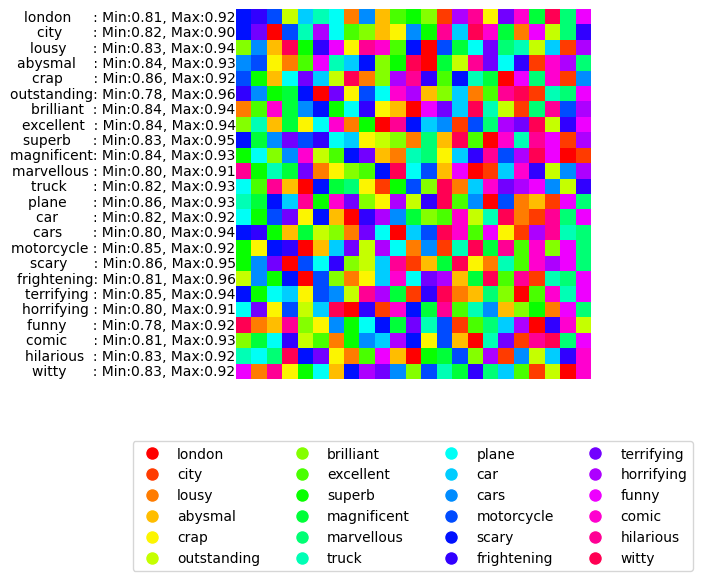

In [19]:
# Create a new folder for this run of the script
if not os.path.exists('color_plots'):
    os.makedirs('color_plots')
plot_filename = f'color_plots/plot_{clauses}.png'

# Create a new 3D array with the same shape as list_of_words, with dtype=np.uint8
color_array = np.zeros((len(list_of_words), len(list_of_words[0]), 3), dtype=np.uint8)

# Loop through each element in the array and replace the word with its corresponding color
for i in range(len(list_of_words)):
    for j in range(len(list_of_words[i])):
        word = list_of_words[i][j]
        # Replace the word with its corresponding color
        color = color_dict[word]
        r, g, b = mcolors.hex2color(color)
        color_array[i][j] = np.array([r*255, g*255, b*255], dtype=np.uint8)

    # Add the row number in front of each row
    plt.text(-0.5, i, f'{target_words_with_min_max[i]}', ha='right', va='center')

# Create a plot of the color array
plt.imshow(color_array)
plt.axis('off')

# Add legends for each word color
legend_handles = []
legend_labels = []
for word, color in color_dict.items():
    legend_handles.append(plt.Line2D([0], [0], marker='o', color='w', label=word, markerfacecolor=color, markersize=10))
    legend_labels.append(word)

plt.legend(handles=legend_handles, labels=legend_labels, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4)

# Save the plot as a PNG file
plt.savefig('color_plots/color_plot.png', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

2023-11-22 15:55:34,910 - matplotlib.font_manager - DEBUG - findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=12.0.
2023-11-22 15:55:34,911 - matplotlib.font_manager - DEBUG - findfont: score(FontEntry(fname='/opt/conda/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/cmss10.ttf', name='cmss10', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2023-11-22 15:55:34,912 - matplotlib.font_manager - DEBUG - findfont: score(FontEntry(fname='/opt/conda/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizFourSymReg.ttf', name='STIXSizeFourSym', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2023-11-22 15:55:34,913 - matplotlib.font_manager - DEBUG - findfont: score(FontEntry(fname='/opt/conda/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizOneSymBol.ttf', name='STIXSizeOneSym', style='normal', variant='normal', weight=700, stre

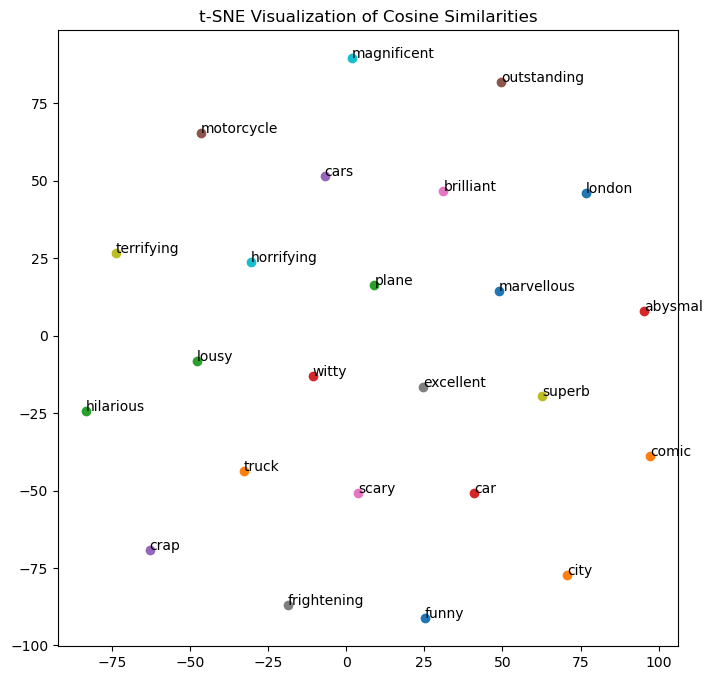

In [20]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Increase the number of samples in the dataset or decrease the perplexity
n_samples = similarity.shape[0]
perplexity = min(30, n_samples - 1)  # You can adjust the perplexity as needed

# Perform t-SNE with adjusted perplexity
tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42)
embeddings = tsne.fit_transform(similarity)

# Plot the results
plt.figure(figsize=(8, 8))
for i, word in enumerate(target_words):
    plt.scatter(embeddings[i, 0], embeddings[i, 1])
    plt.text(embeddings[i, 0], embeddings[i, 1], word)

plt.title('t-SNE Visualization of Cosine Similarities')
plt.show()